<a href="https://colab.research.google.com/github/nicolenelson10/credit-card-fraud-detection-ml/blob/feature%2Fmodel-evaluation/04_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Evaluation and Comparison

## Machine Learning-Based Credit Card Fraud Detection

This notebook compares the performance of Logistic Regression and Random Forest models using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

The main objective is to understand model performance under severe class imbalance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Logistic Regression results

lr_accuracy = 0.9754924335521927
lr_precision = 0.06089309878213803
lr_recall = 0.9183673469387755
lr_f1 = 0.11421319796954314

lr_cm = np.array([
    [55476, 1388],
    [8, 90]
])

print("Logistic Regression results loaded successfully!")

Logistic Regression results loaded successfully!


In [ ]:
# Random Forest results

rf_accuracy = 0.9995084442259752
rf_precision = 0.9605263157894737
rf_recall = 0.7448979591836735
rf_f1 = 0.8390804597701149

rf_cm = np.array([
    [56861, 3],
    [25, 73]
])

print("Random Forest results loaded successfully!")

Random Forest results loaded successfully!


In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1-Score": [lr_f1, rf_f1]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.975492,0.060893,0.918367,0.114213
1,Random Forest,0.999508,0.960526,0.744898,0.839080


In [ ]:
results_percentage = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_percentage[column] = results_percentage[column] * 100

results_percentage.round(2)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,97.55,6.09,91.84,11.42
1,Random Forest,99.95,96.05,74.49,83.91


In [ ]:
results_percentage = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_percentage[column] = results_percentage[column] * 100

results_percentage.round(2)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,97.55,6.09,91.84,11.42
1,Random Forest,99.95,96.05,74.49,83.91


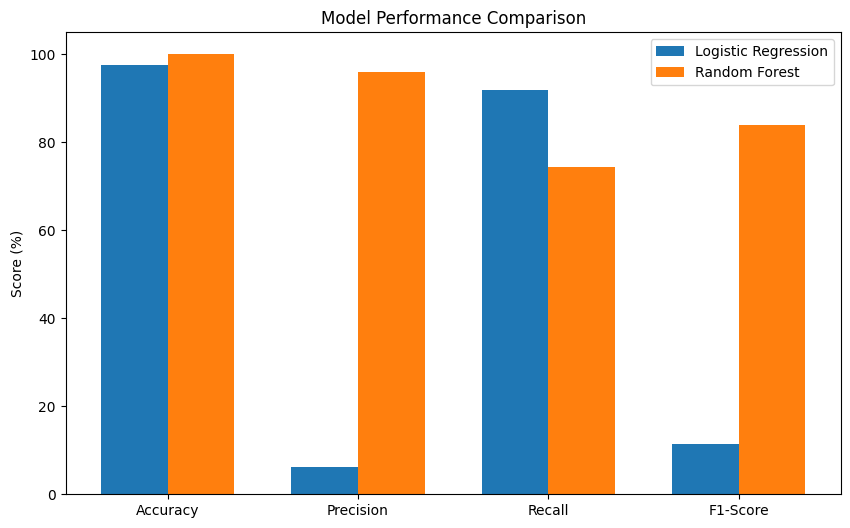

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    results_percentage.loc[0, metrics],
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width/2,
    results_percentage.loc[1, metrics],
    width,
    label="Random Forest"
)

plt.xticks(x, metrics)
plt.ylabel("Score (%)")
plt.title("Model Performance Comparison")
plt.ylim(0, 105)
plt.legend()
plt.show()

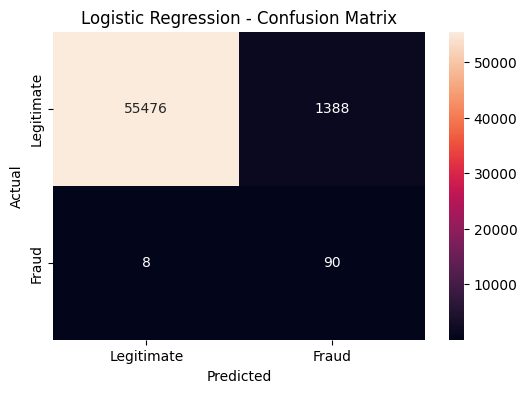

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

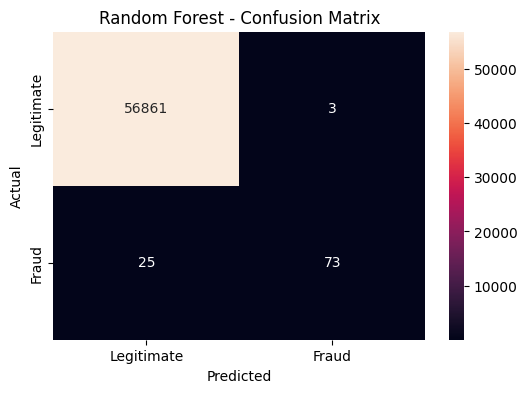

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
print("Logistic Regression")
print("-------------------")
print("True Negatives :", lr_cm[0, 0])
print("False Positives:", lr_cm[0, 1])
print("False Negatives:", lr_cm[1, 0])
print("True Positives :", lr_cm[1, 1])

print("\nRandom Forest")
print("-------------")
print("True Negatives :", rf_cm[0, 0])
print("False Positives:", rf_cm[0, 1])
print("False Negatives:", rf_cm[1, 0])
print("True Positives :", rf_cm[1, 1])

Logistic Regression
-------------------
True Negatives : 55476
False Positives: 1388
False Negatives: 8
True Positives : 90

Random Forest
-------------
True Negatives : 56861
False Positives: 3
False Negatives: 25
True Positives : 73


## Understanding the Evaluation Metrics

### Accuracy
Accuracy represents the overall percentage of correctly classified transactions.

### Precision
Precision represents how many transactions predicted as fraudulent were actually fraudulent.

### Recall
Recall represents how many of the actual fraudulent transactions were correctly detected.

### F1-Score
F1-Score is the harmonic mean of precision and recall and provides a balance between the two metrics.

### Confusion Matrix
The confusion matrix shows:

- True Positive (TP): Fraud correctly detected
- True Negative (TN): Legitimate transaction correctly identified
- False Positive (FP): Legitimate transaction incorrectly classified as fraud
- False Negative (FN): Fraud incorrectly classified as legitimate

## Why Accuracy Alone Is Not Enough

The credit card fraud dataset is highly imbalanced, with approximately 99.83% legitimate transactions and only 0.17% fraudulent transactions.

Because the majority class is much larger than the minority class, a model can achieve high accuracy while still performing poorly on fraud detection.

Therefore, Precision, Recall, F1-Score, and the Confusion Matrix are also important for evaluating fraud detection models.

## Model Comparison

The Logistic Regression model achieved an accuracy of 97.55%, precision of 6.09%, recall of 91.84%, and F1-score of 11.42%.

The Random Forest model achieved an accuracy of 99.95%, precision of 96.05%, recall of 74.49%, and F1-score of 83.91%.

Logistic Regression detected a larger proportion of the actual fraudulent transactions, resulting in higher recall. However, it produced many more false positive alerts.

Random Forest produced very few false positives and achieved much higher precision and F1-score, while its recall was lower than Logistic Regression.

This demonstrates the trade-off between precision and recall in fraud detection.

# Conclusion

This project evaluated Logistic Regression and Random Forest for credit card fraud detection under severe class imbalance.

The results show that accuracy alone is not sufficient for evaluating fraud detection models.

Logistic Regression achieved higher recall, detecting more of the fraudulent transactions, but generated a larger number of false positive alerts.

Random Forest achieved higher precision and F1-score, with significantly fewer false positives, but missed more fraudulent transactions than Logistic Regression.

Therefore, different evaluation metrics provide different perspectives on model performance. The appropriate model depends on the application's priorities, such as minimizing missed fraud or reducing false alerts.